In [27]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, cross_validate
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix,make_scorer, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from joblib import dump

In [28]:
import os
os.chdir(os.getcwd())

# Establishes global variables to be used through the training program

In [29]:
testsize=0.4 # 40% of the total data will be preserved for testing
significant=5
file = "Training data.xlsx" #Filename for training data 


neighbors=3
data =pd.read_excel(file,header=0,index_col=0)

# Minerals names are converted to their respective mineral classes
cond = (data['Mineral']=="Act/Tr") | (data['Mineral']=="Fe-Mg Amp") | (data['Mineral']=="Hbl") | (data['Mineral']=="Na-Amp")
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
data.loc[cond,"Mineral"] = "Amp"
data.pop('Source')

plt.rc('font',size=10,family='serif')
figsize=(10,10)
lw = 1

data1 = data.copy() # Done to preserve the original training data for start of each run

# parameters = {'n_neighbors' : np.arange(1,11,2), 'weights': ['uniform','distance'],
#              'algorithm':['ball_tree','kd_tree','brute'],'leaf_size':np.arange(1,11,2)}
# model_test = KNeighborsClassifier()
# model = GridSearchCV(model_test, param_grid=parameters,verbose=4,scoring=f1,cv=5,n_jobs=6)

model = KNeighborsClassifier(algorithm='brute',n_neighbors=neighbors,weights="distance") # Tuned Hyper-parameters determined from the commented out codes above.
over_metrics="macro"
sample_metrics="weighted"


Testing for raw input (C1) data

99.93
{'fit_time': array([0.        , 0.00200272, 0.00200272, 0.00400448, 0.00374579,
       0.00592422, 0.00200248, 0.00200272, 0.0020051 , 0.00377035]), 'score_time': array([0.03845   , 0.02982211, 0.03002477, 0.02989054, 0.0260601 ,
       0.03354478, 0.03155351, 0.03086329, 0.03068495, 0.02630758]), 'test_score': array([0.99840595, 0.9978746 , 0.9978746 , 0.99946837, 0.99893674,
       0.99787347, 1.        , 0.99893674, 0.99787347, 0.99734184])}
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 99.97
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.91
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.79
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C1.lbl']

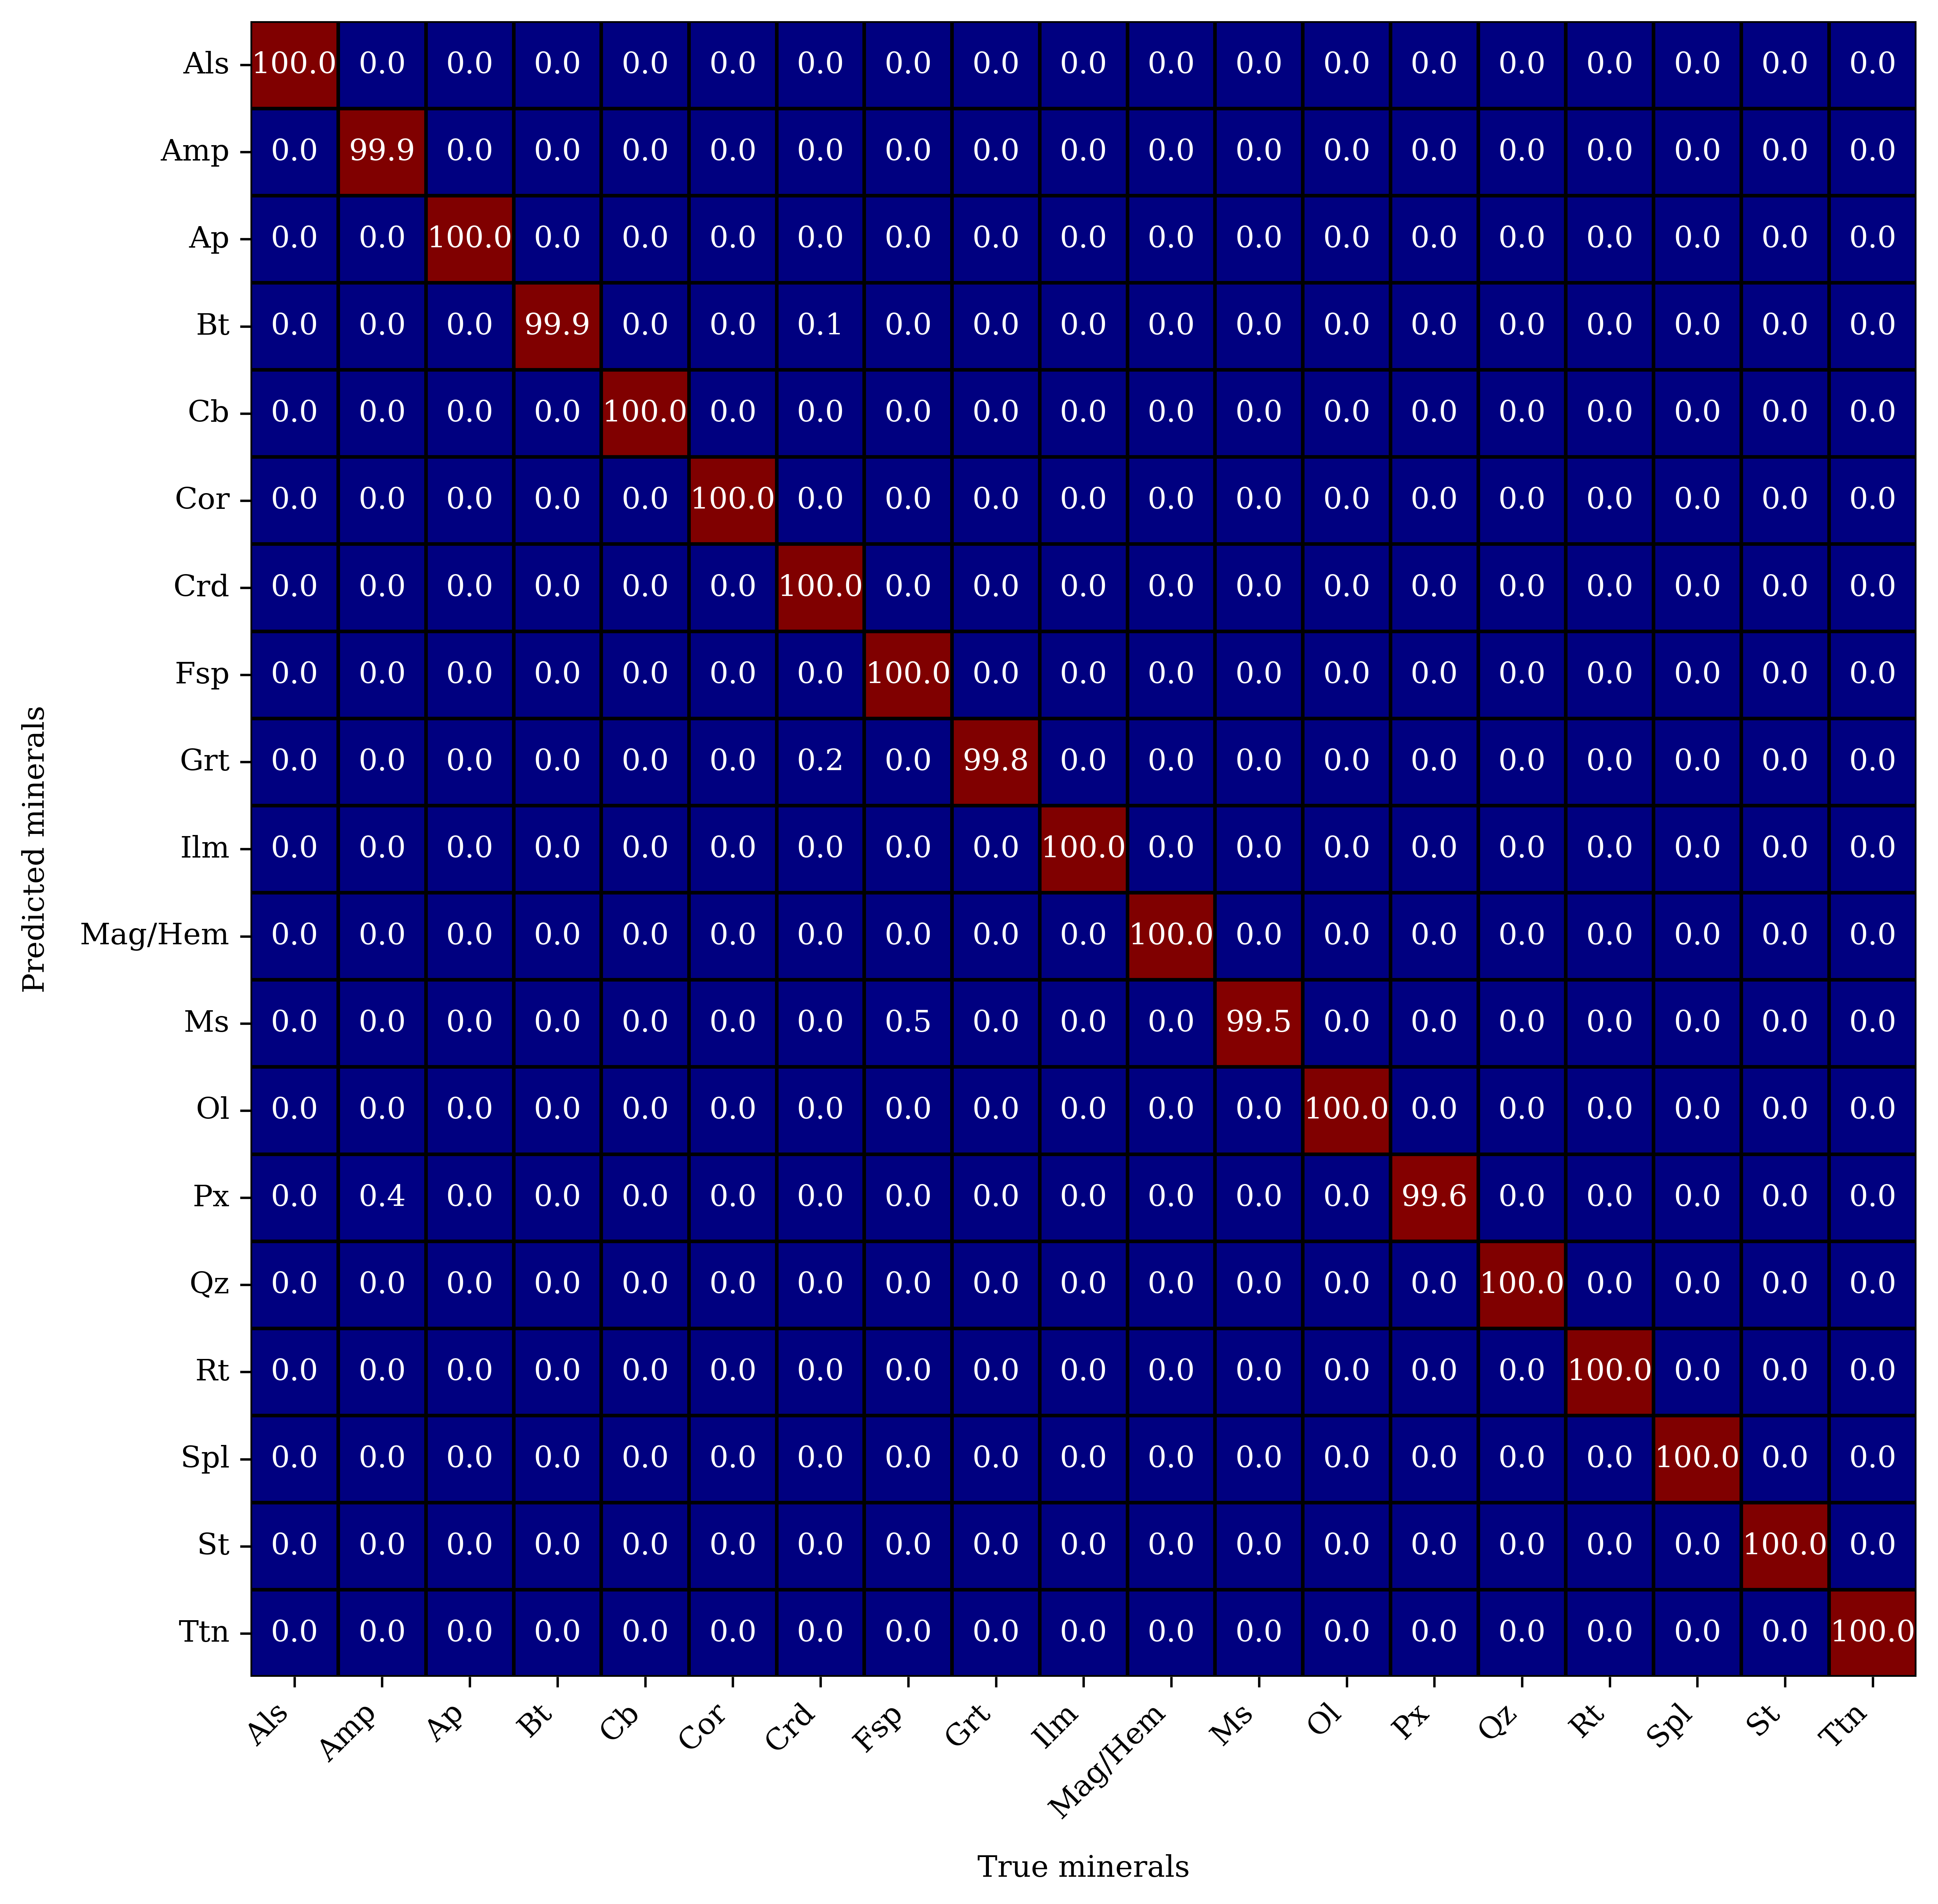

In [30]:
data = data1.copy()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

ncol = 5
minerals = len(labeler.classes_)+1
acc_table = np.zeros((minerals,ncol))
recall_table = np.zeros((minerals,ncol))
precision_table = np.zeros((minerals,ncol))


splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for raw input (C1) data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,0] = a
precision_table[0,0] = p
recall_table[0,0] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C1.pdf",bbox_inches='tight')

score = cross_validate(model,test_data,test_label,scoring='f1_micro',cv=10)
print(score)
for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,0] = a
    precision_table[i+1,0] = p
    recall_table[i+1,0] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
test_data_df_mismatch

dump(model,"KNN_C1.mdl")
dump(scaler,"Scaler_C1.scl")
dump(labeler,"Labeler_C1.lbl")

In [31]:
tdata = data.iloc[split1[1],:]
tdata.to_excel(r"Original_testing_data.xlsx") # Original testing data is preserved

In [32]:
print(test_data_df_mismatch.shape[0])
test_data_df_mismatch

19


,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,,,
30894,53.4,0.0,0.0,20.2,3.6,10.2,12.7,0.0,0.0,0.0,0.0,Amp,Grt
31822,48.7,0.0,0.0,17.7,0.0,20.5,13.2,0.0,0.0,0.0,0.0,Amp,Px
13987,43.1,0.0,13.1,14.6,10.7,11.2,0.0,0.0,7.2,0.0,0.0,Bt,Crd
42902,42.8,0.0,14.5,21.5,13.5,0.0,7.7,0.0,0.0,0.0,0.0,Grt,Crd
43696,42.5,0.0,14.8,24.3,13.9,4.5,0.0,0.0,0.0,0.0,0.0,Grt,Crd
7233,61.8,0.0,30.2,0.0,0.0,0.0,0.0,5.2,2.7,0.0,0.0,Ms,Fsp
7232,61.2,0.0,30.0,0.0,0.0,0.0,0.0,6.9,2.0,0.0,0.0,Ms,Fsp
29195,48.8,0.0,3.5,12.5,0.0,23.8,11.4,0.0,0.0,0.0,0.0,Px,Amp
29199,49.1,0.0,1.2,15.4,0.0,21.2,13.1,0.0,0.0,0.0,0.0,Px,Amp



Testing for FeO+MnO+MgO input data (C2)

99.96
Als: accuracy: 100.0
Amp: accuracy: 99.98
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.88
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C2.lbl']

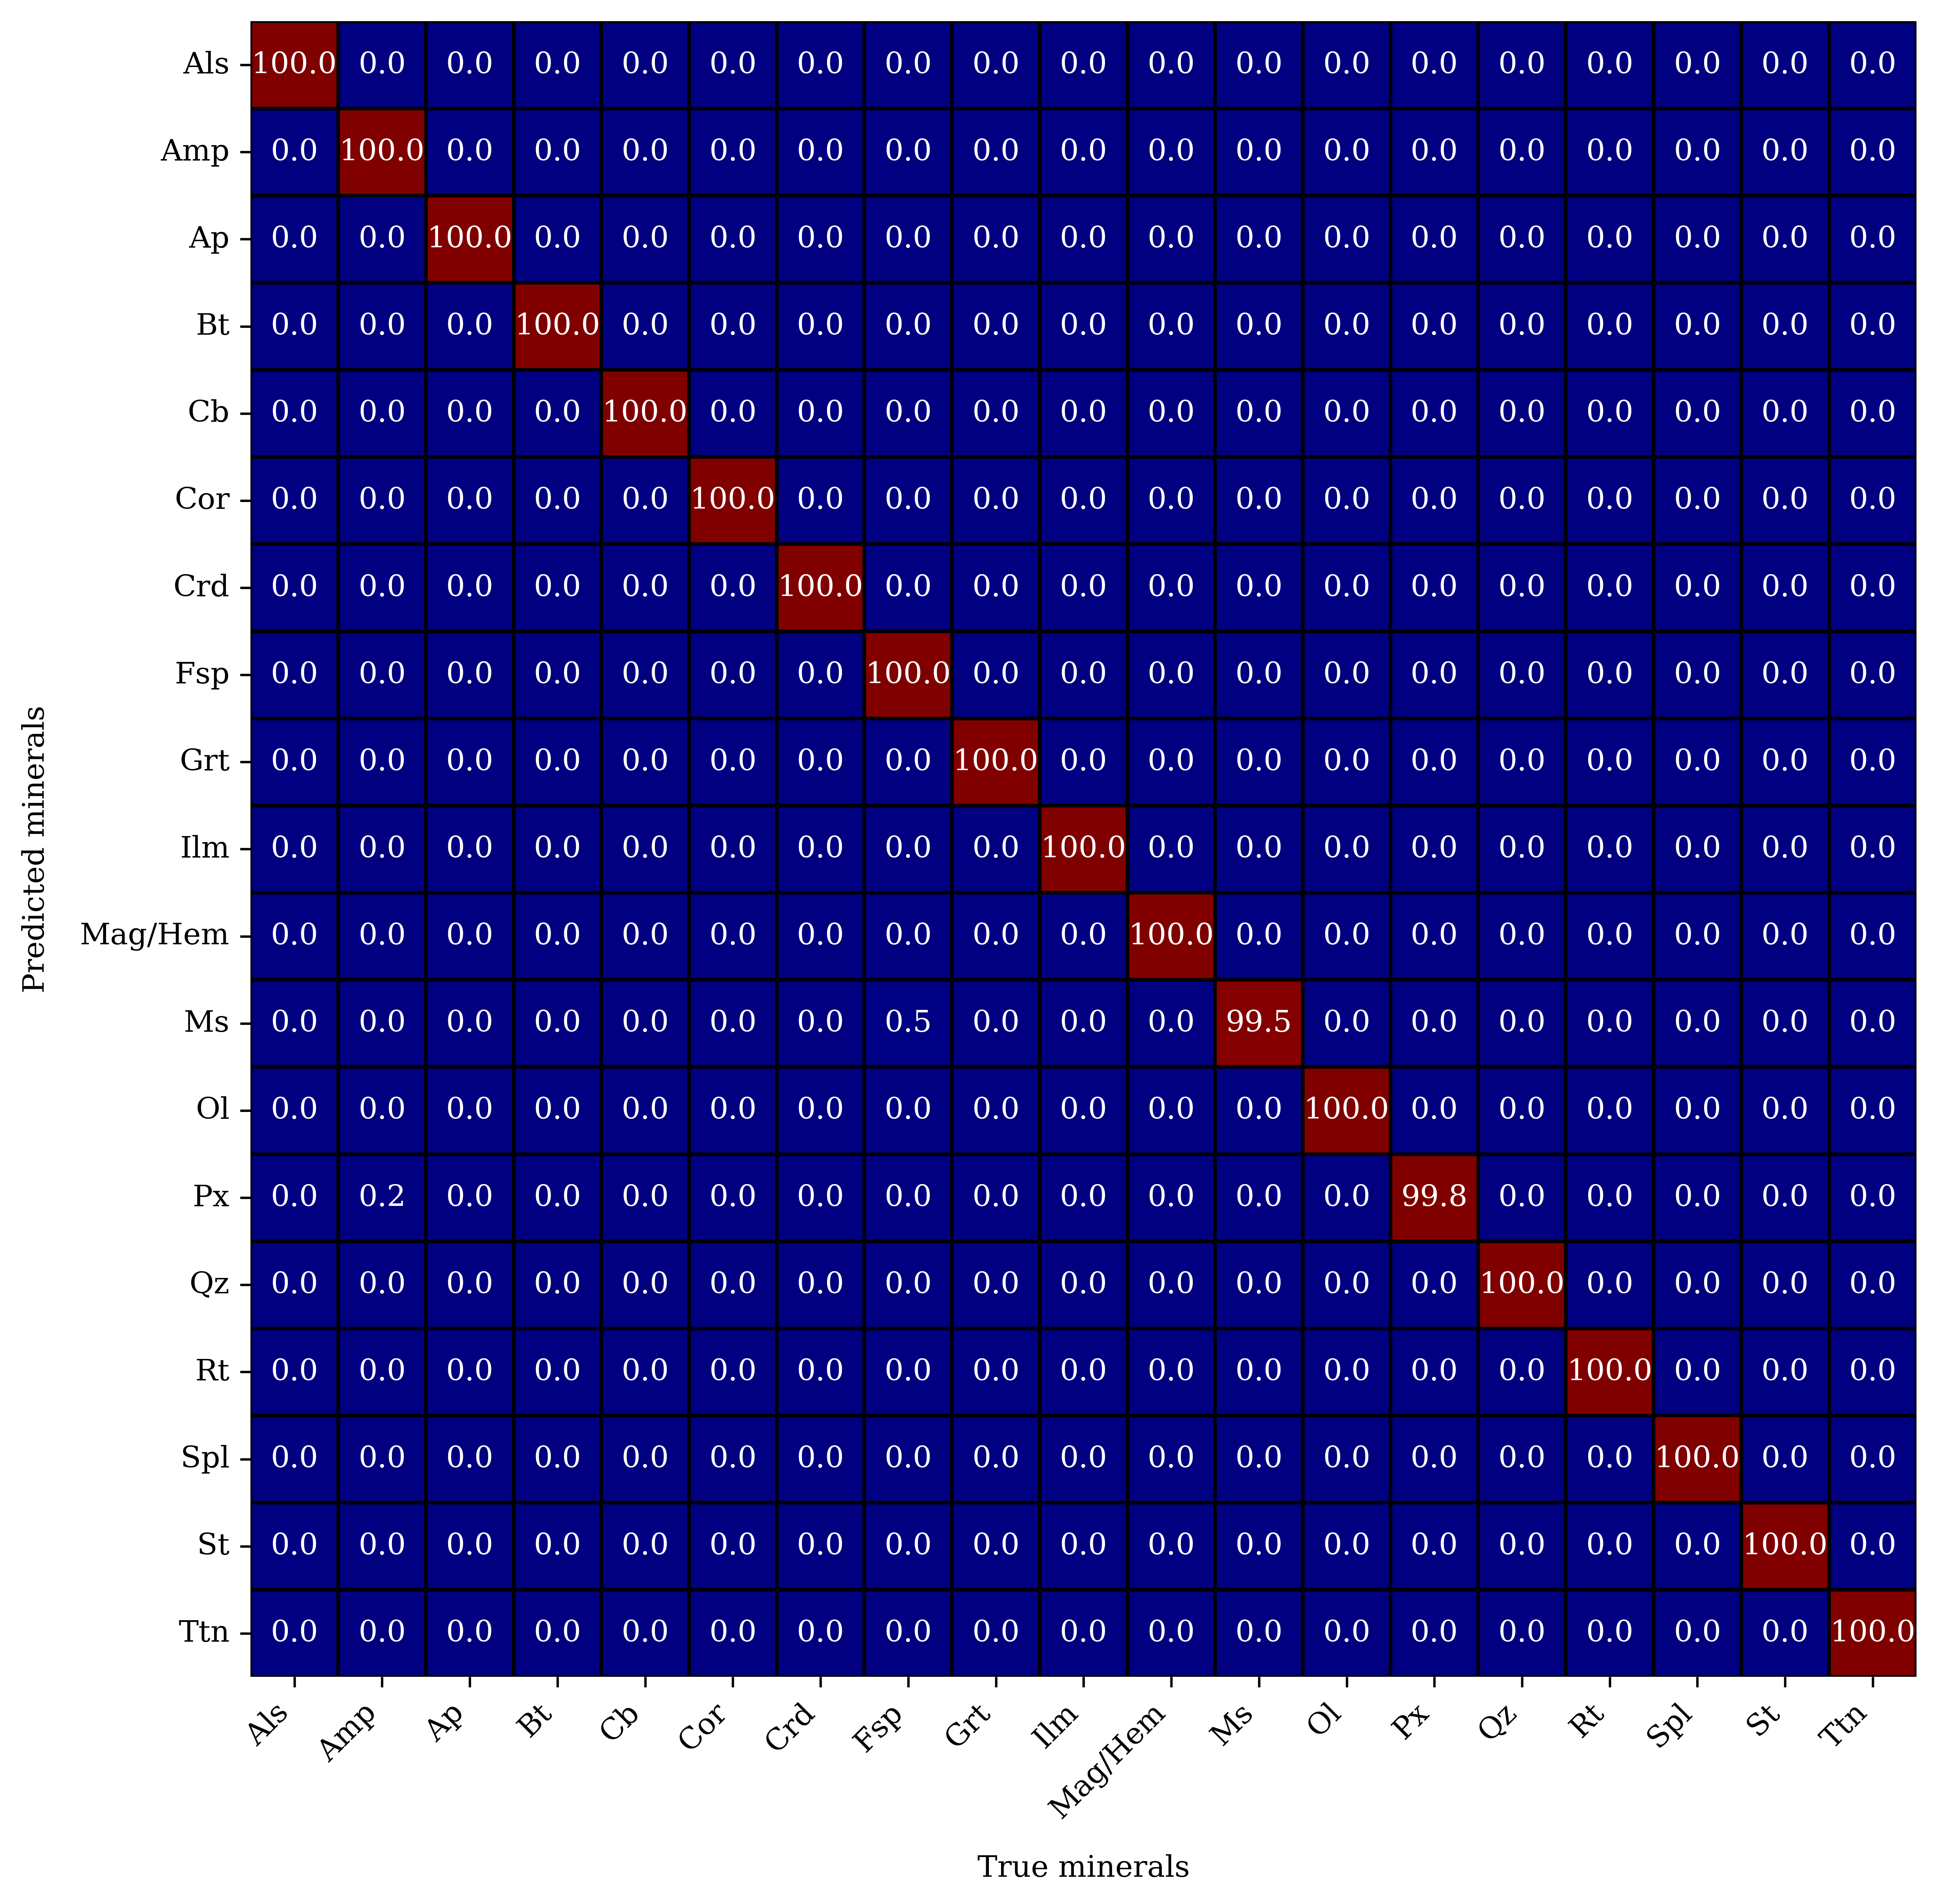

In [33]:
data=data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")

data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'Na2O', 'K2O', 'P2O5','CO2', 'Mineral']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO input data (C2)\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,1] = a
precision_table[0,1] = p
recall_table[0,1] = r
print(round(a,2))
cm = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C2.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,1] = a
    precision_table[i+1,1] = p
    recall_table[i+1,1] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]

dump(model,"KNN_C2.mdl")
dump(scaler,"Scaler_C2.scl")
dump(labeler,"Labeler_C2.lbl")

In [34]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,M,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,
31822,48.7,0.0,0.0,38.2,13.2,0.0,0.0,0.0,0.0,Amp,Px
7233,61.8,0.0,30.2,0.0,0.0,5.2,2.7,0.0,0.0,Ms,Fsp
7232,61.2,0.0,30.0,0.0,0.0,6.9,2.0,0.0,0.0,Ms,Fsp
29185,49.3,0.0,1.9,35.2,13.7,0.0,0.0,0.0,0.0,Px,Amp
29215,53.5,0.0,0.0,41.6,4.9,0.0,0.0,0.0,0.0,Px,Amp
29138,48.2,0.0,3.4,32.4,15.9,0.0,0.0,0.0,0.0,Px,Amp
28559,49.7,0.0,4.8,30.4,15.0,0.0,0.0,0.0,0.0,Px,Amp
28739,48.3,0.0,2.5,35.4,13.8,0.0,0.0,0.0,0.0,Px,Amp
28247,48.7,0.0,2.7,35.5,13.1,0.0,0.0,0.0,0.0,Px,Amp



Testing for M (= FeO + MnO + MgO) and A(= Na2O + K2O) input data

99.99
Als: accuracy: 100.0
Amp: accuracy: 99.98
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.88
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C3.lbl']

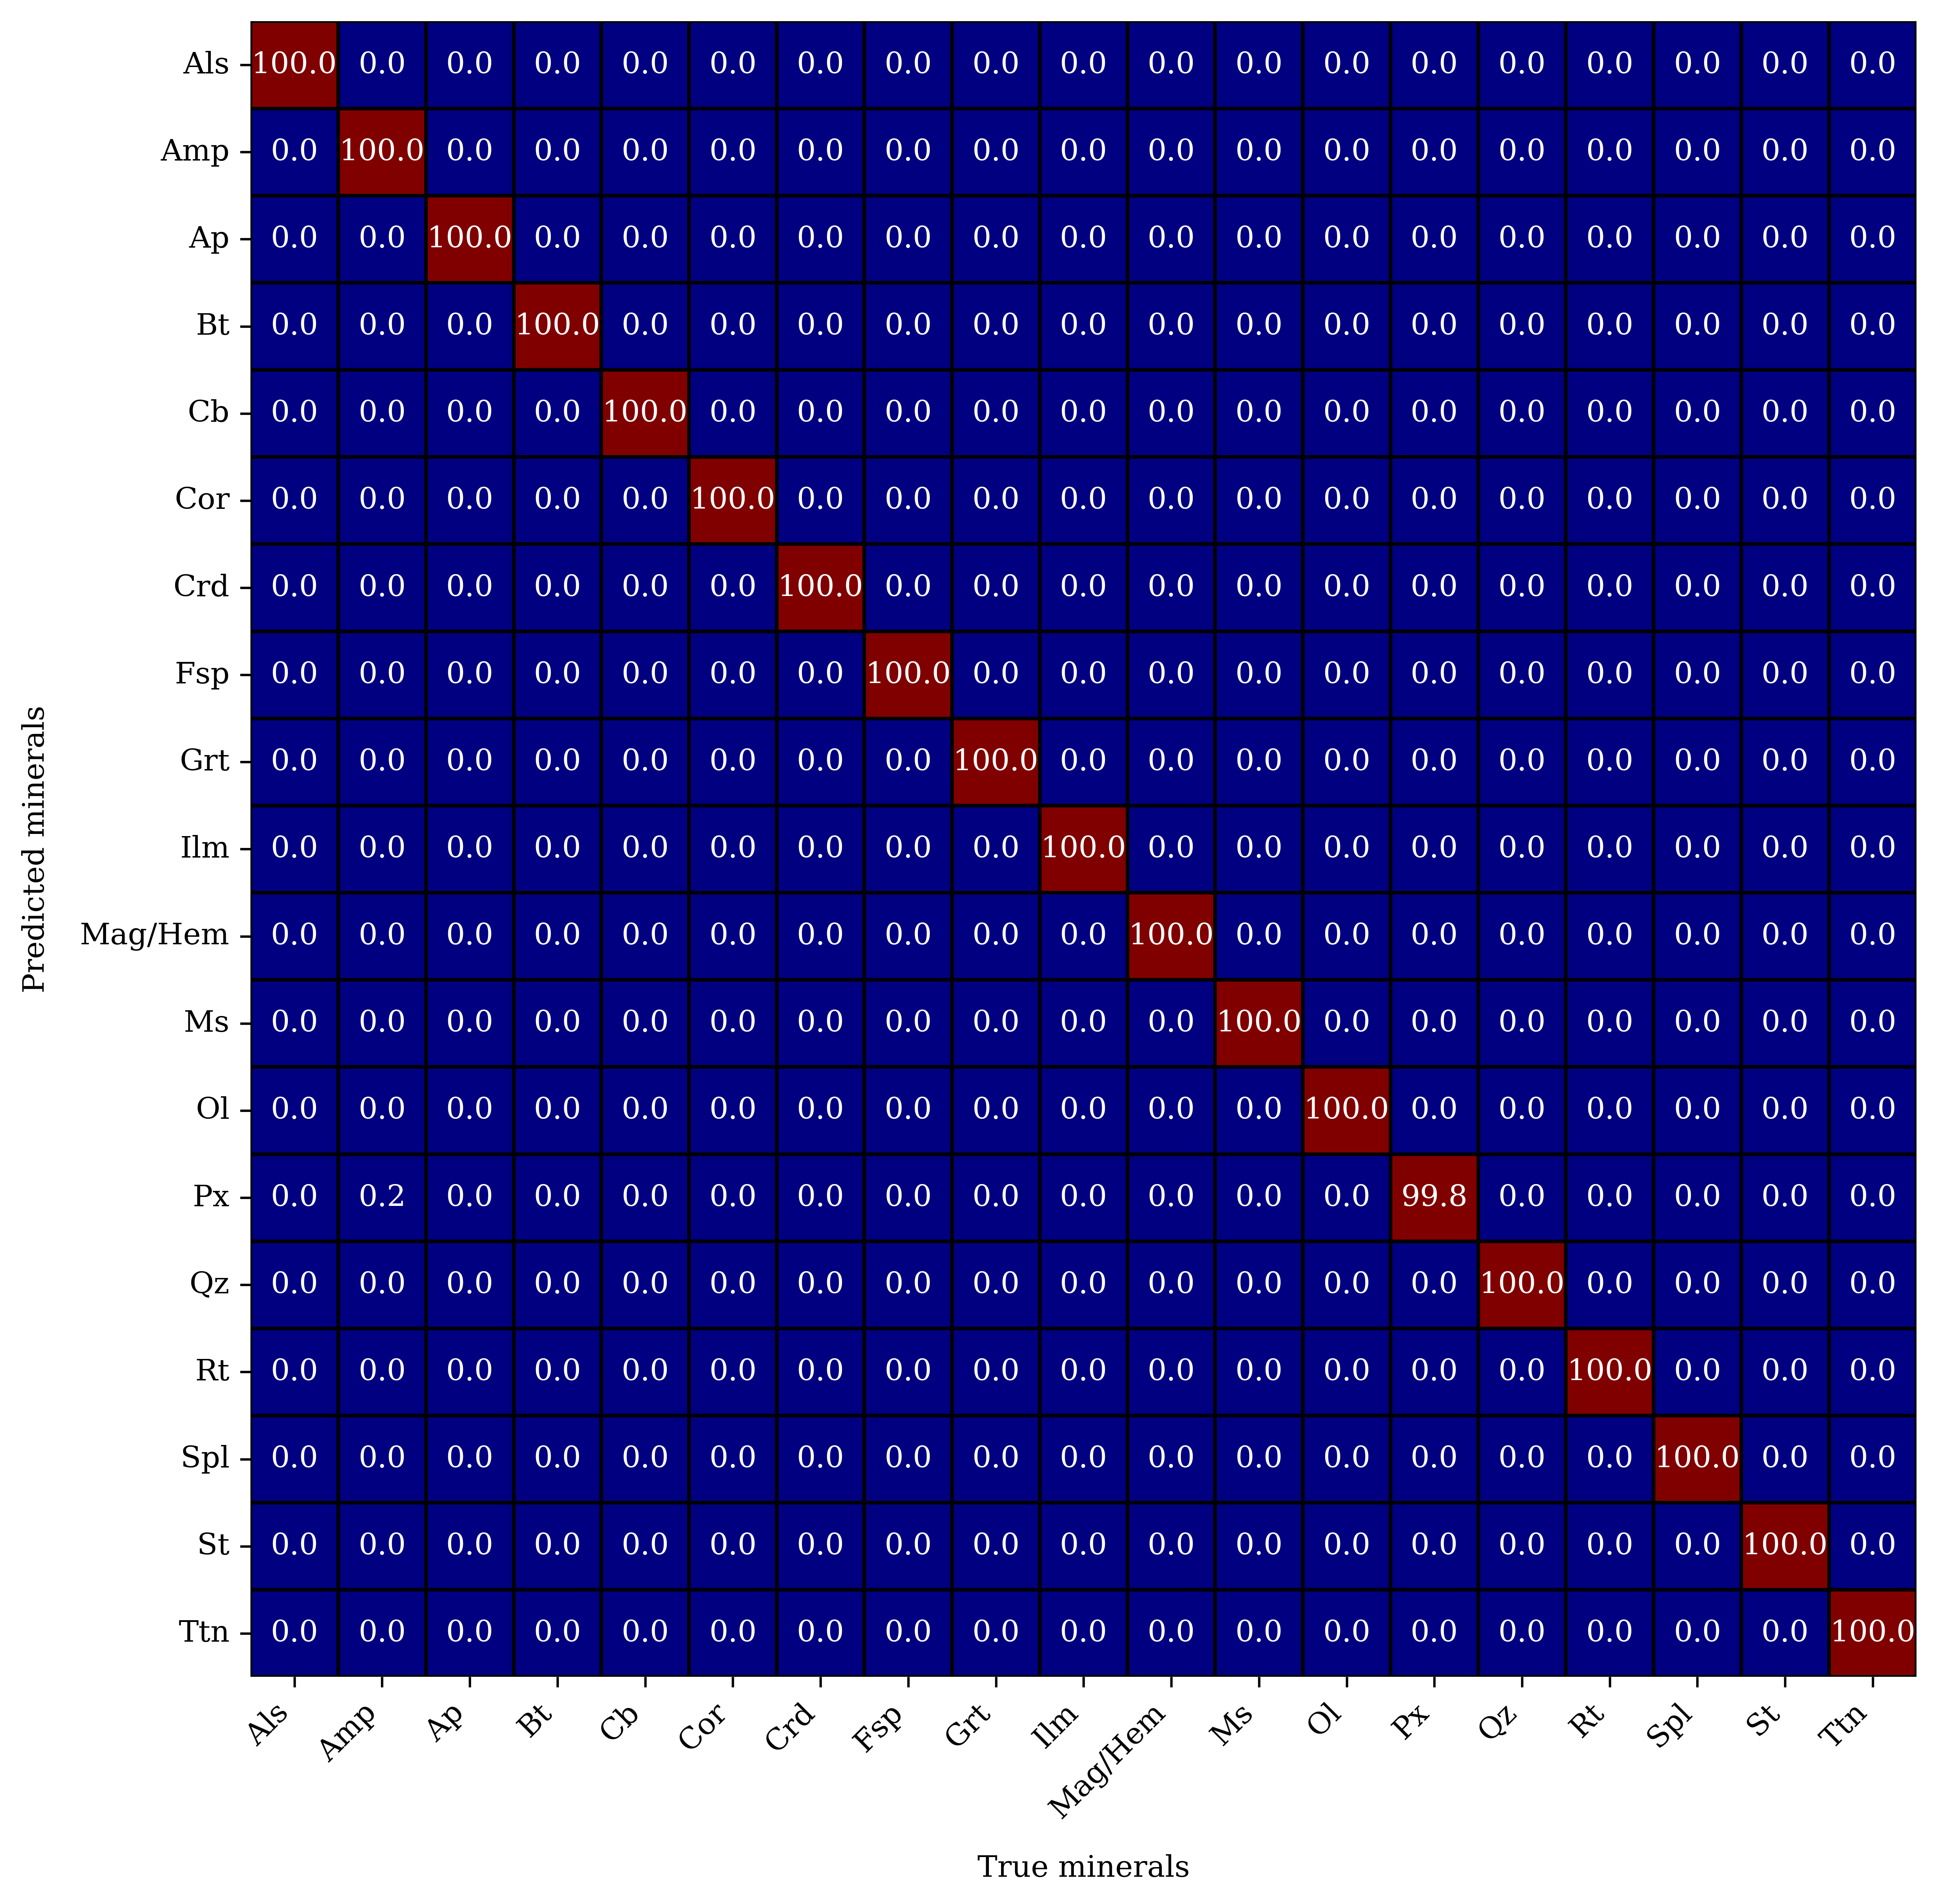

In [35]:
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']#+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")
# data.pop("CaO")

data['A'] = data["K2O"]+data["Na2O"]
data.pop("K2O")
data.pop("Na2O")
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'P2O5', 'CO2','Mineral']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for M (= FeO + MnO + MgO) and A(= Na2O + K2O) input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
# print(round(a,2))
# acc_table[0,2] = a

a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,2] = a
precision_table[0,2] = p
recall_table[0,2] = r
# print(round(a,2p = pd.DataFrame(confusion_matrix(test_label, pred_label),columns=labeler.classes_,index=labeler.classes_plt.figure(figsize=(16,16),dpi=600)
print(round(a,2))
cm = confusion_matrix(test_label, pred_label,normalize='true')*100
cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("KNN_C3.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,2] = a
    precision_table[i+1,2] = p
    recall_table[i+1,2] = r
    acc_table[i+1,2] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

dump(model,"KNN_C3.mdl")
dump(scaler,"Scaler_C3.scl")
dump(labeler,"Labeler_C3.lbl")

In [36]:
test_data_df_mismatch

,SiO2,TiO2,Al2O3,M,CaO,Na2O,K2O,P2O5,CO2,Mineral,Pred
S No.,,,,,,,,,,,
31822,48.7,0.0,0.0,38.2,13.2,0.0,0.0,0.0,0.0,Amp,Px
7233,61.8,0.0,30.2,0.0,0.0,5.2,2.7,0.0,0.0,Ms,Fsp
7232,61.2,0.0,30.0,0.0,0.0,6.9,2.0,0.0,0.0,Ms,Fsp
29185,49.3,0.0,1.9,35.2,13.7,0.0,0.0,0.0,0.0,Px,Amp
29215,53.5,0.0,0.0,41.6,4.9,0.0,0.0,0.0,0.0,Px,Amp
29138,48.2,0.0,3.4,32.4,15.9,0.0,0.0,0.0,0.0,Px,Amp
28559,49.7,0.0,4.8,30.4,15.0,0.0,0.0,0.0,0.0,Px,Amp
28739,48.3,0.0,2.5,35.4,13.8,0.0,0.0,0.0,0.0,Px,Amp
28247,48.7,0.0,2.7,35.5,13.1,0.0,0.0,0.0,0.0,Px,Amp


In [37]:
acc_table

array([[ 99.93,  99.96,  99.99,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [ 99.96,  99.98,  99.98,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [ 99.97, 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [ 99.91, 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [ 99.76,  99.76, 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [ 99.79,  99.88,  99.88,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ],
       [100.  , 100.  , 100.  ,   0.  ,   0.  ]])


Testing for PCA (n=5) transformed input data (C4)

99.94
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 99.95
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.81
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0

Testing for PCA (n=6) transformed input data (C4)

99.92
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 99.95
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.91
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.81
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


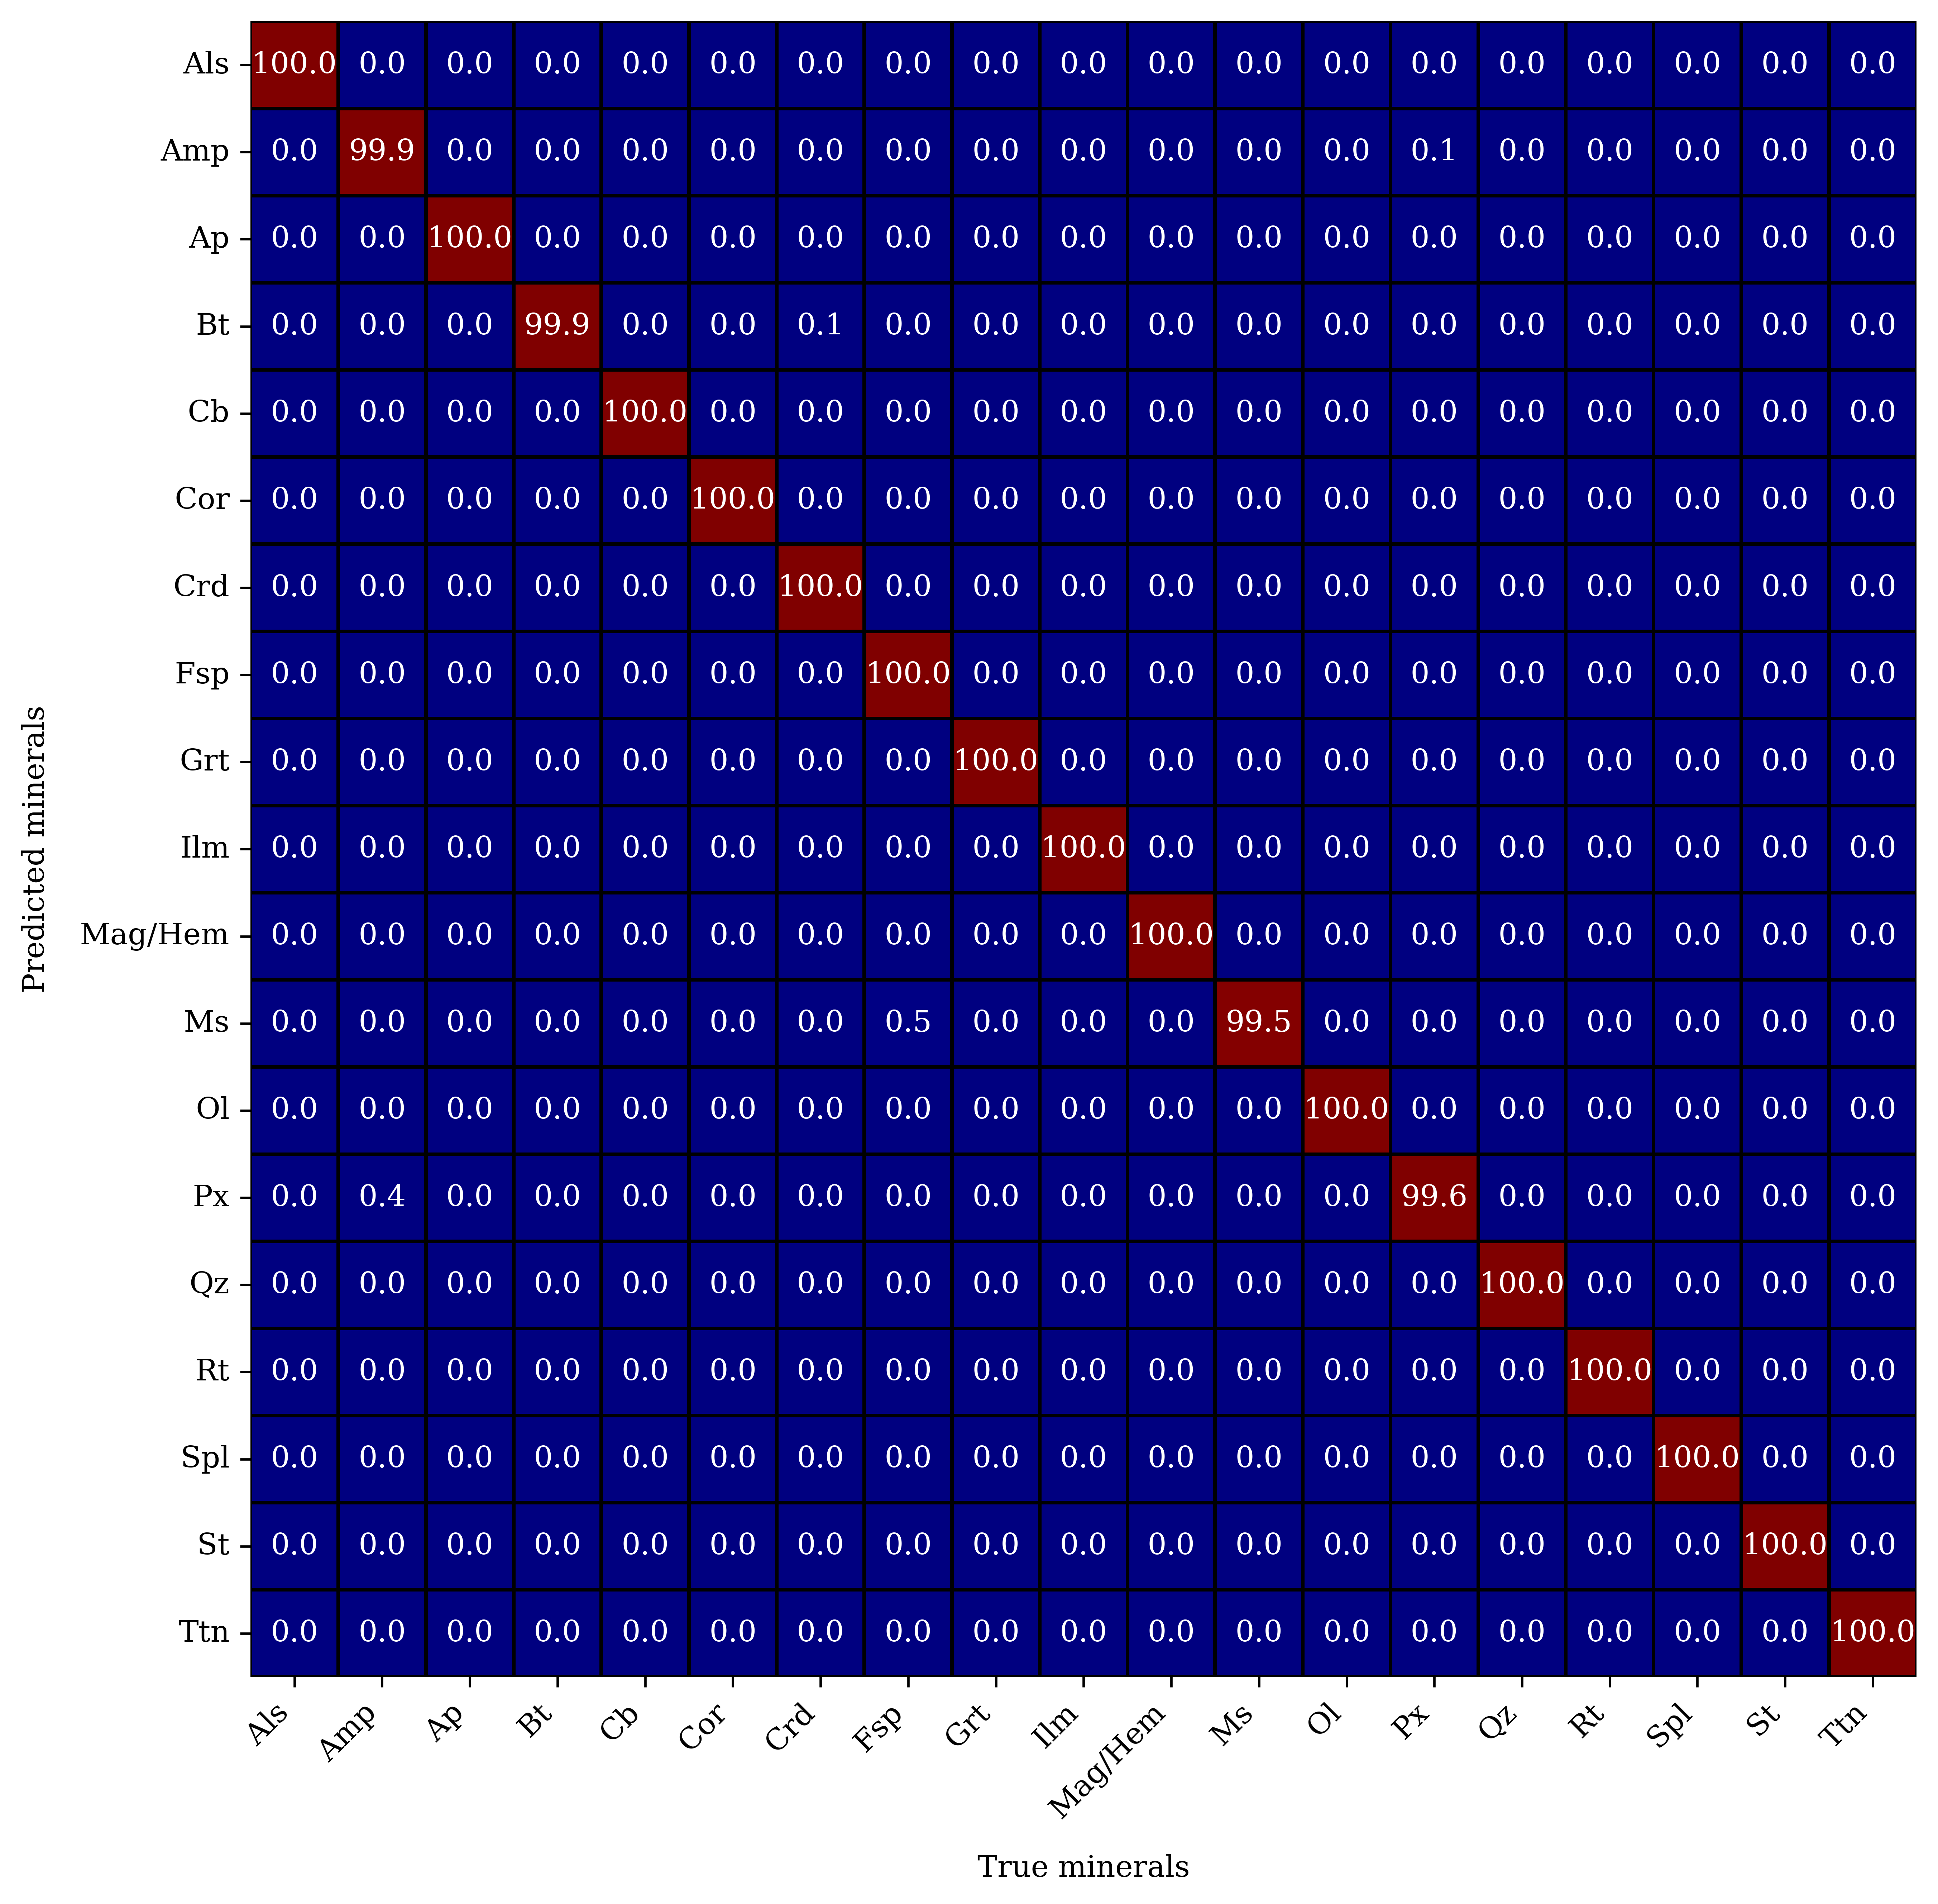

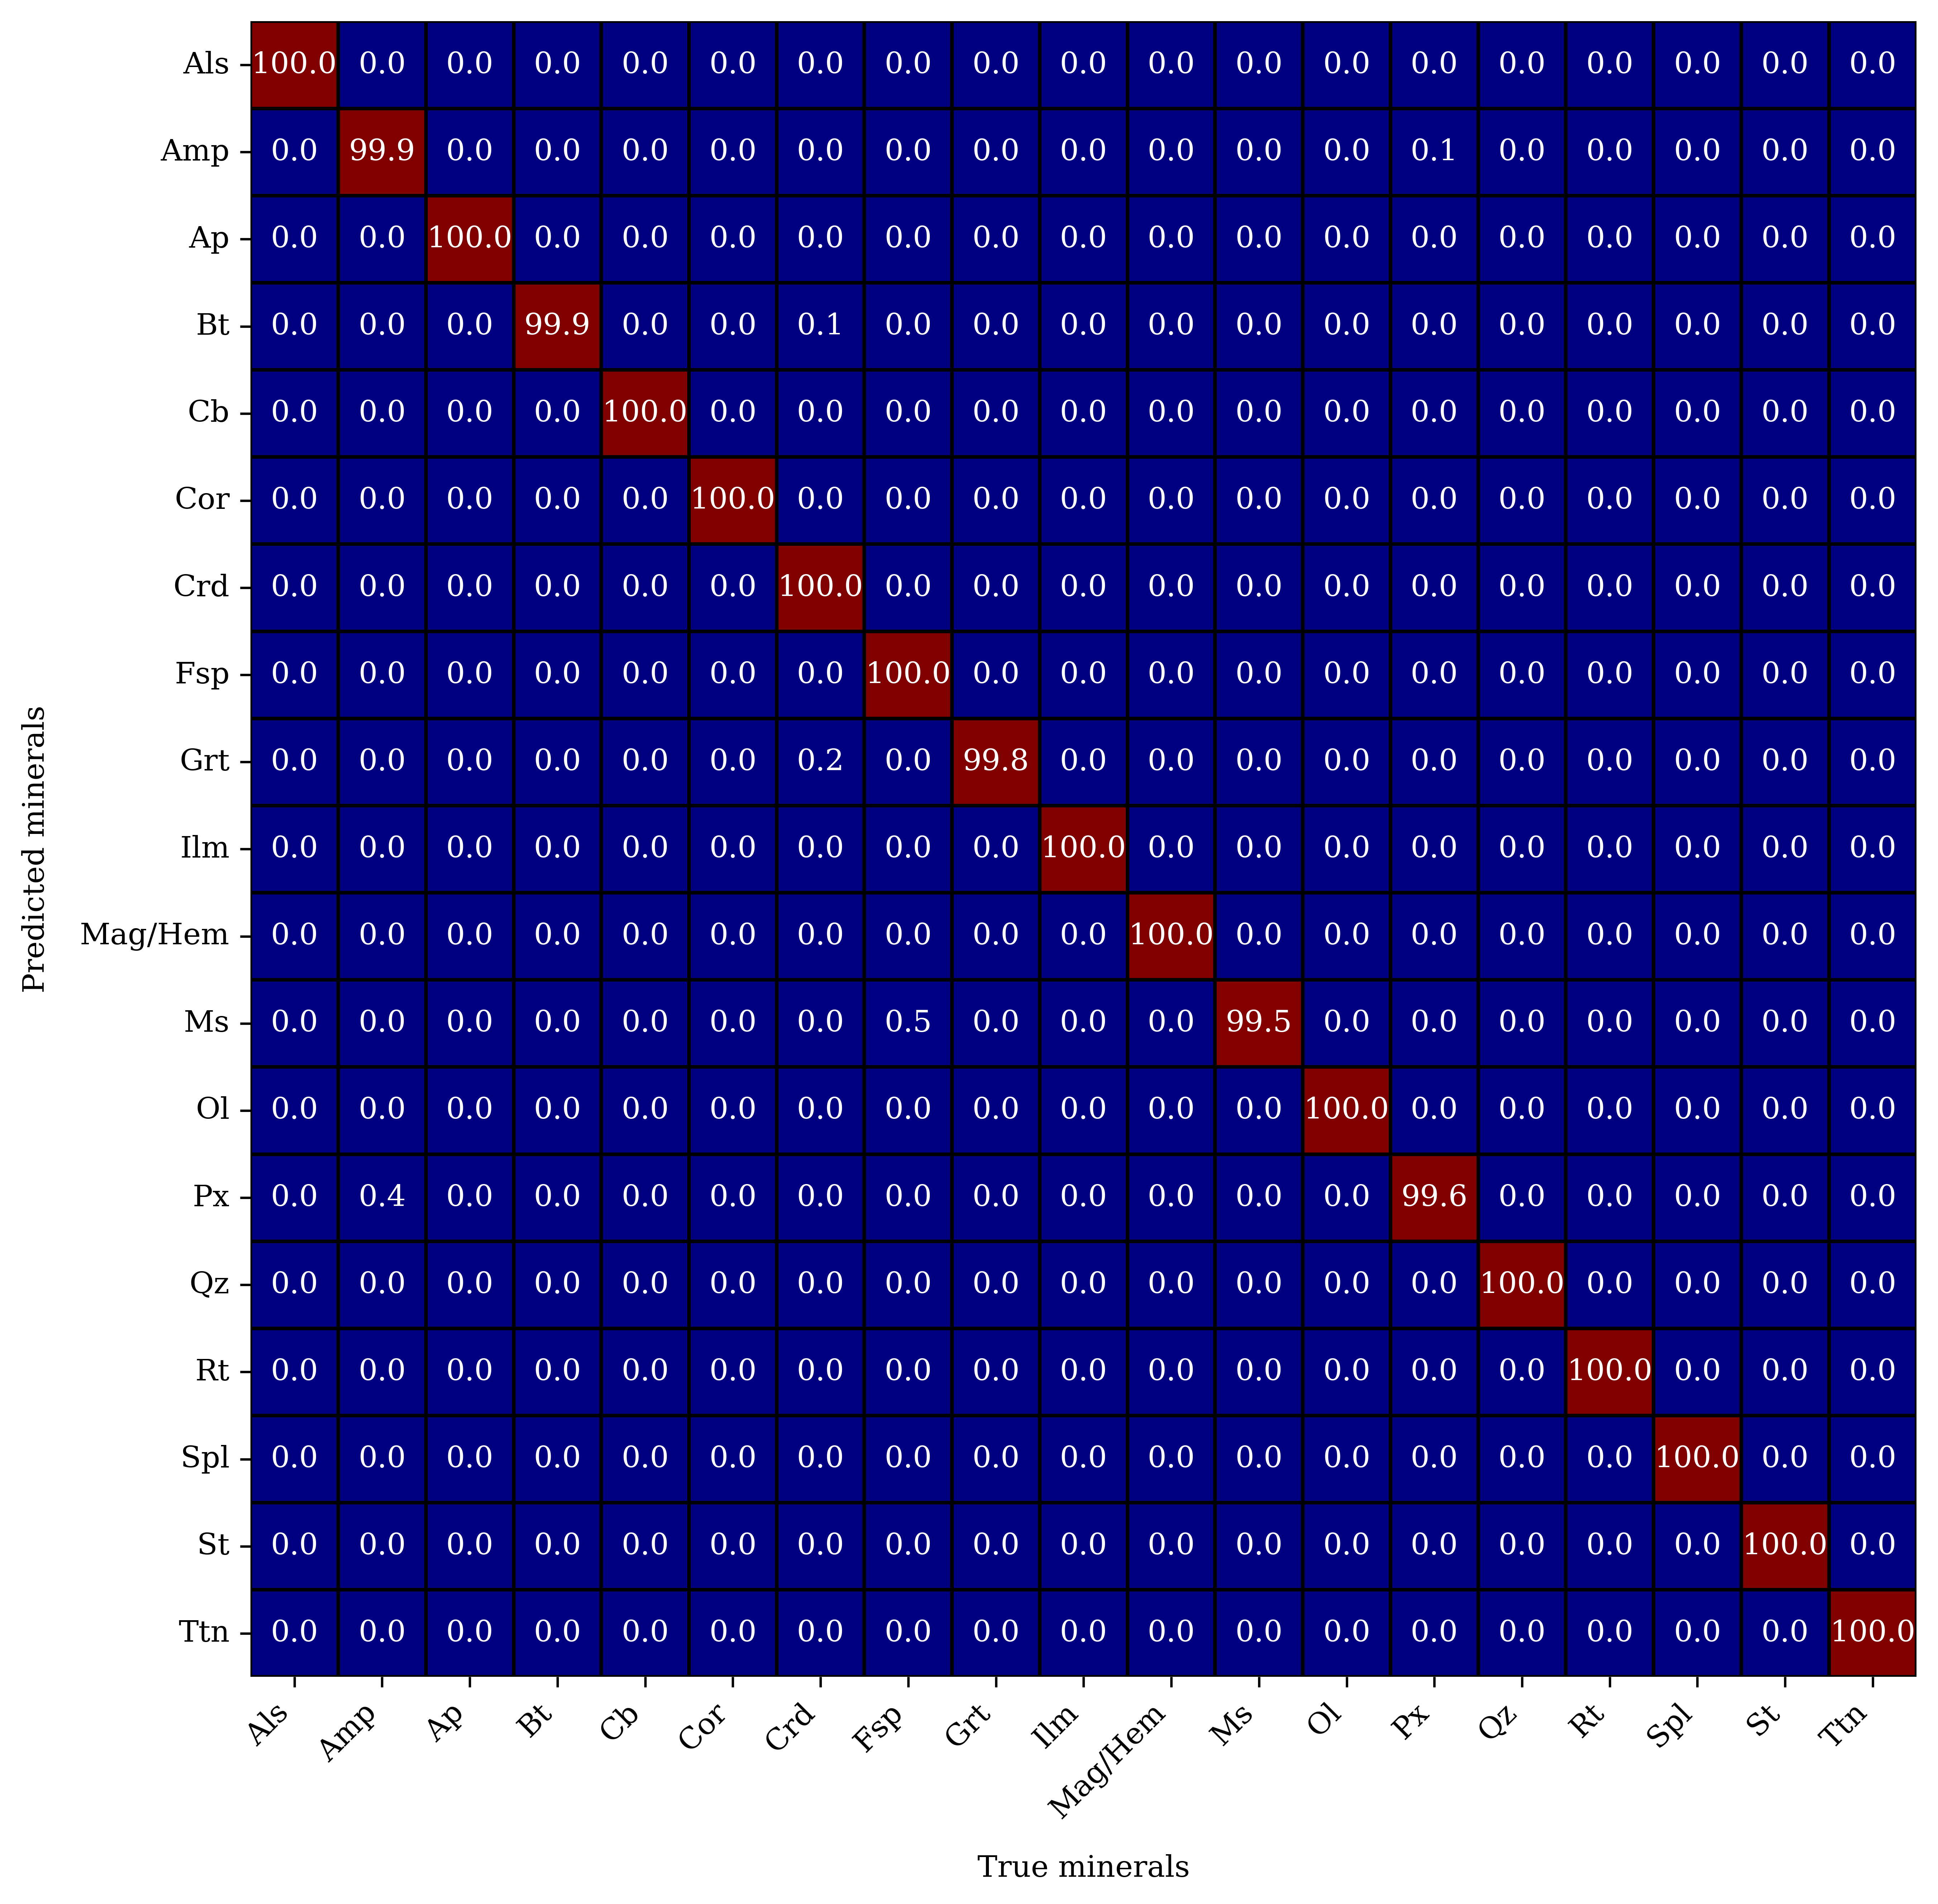

In [38]:
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-1])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

for i in range(5,7):
    
    print(f"\nTesting for PCA (n={i}) transformed input data (C4)\n")
    data_scaled = data_scaled.copy()
    pca = PCA(n_components=i,svd_solver="full")
    pca_normalized_data = pca.fit_transform(data_scaled)
    train_data = pca_normalized_data[split1[0],:]
    train_label = target[split1[0]]
    test_data = pca_normalized_data[split1[1],:]
    test_label = target[split1[1]]
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    # a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
    
    a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    acc_table[0,i-2] = a
    precision_table[0,i-2] = p
    recall_table[0,i-2] = r
    print(round(a,2))
    # acc_table[0,i+3] = a
    cm = confusion_matrix(test_label, pred_label,normalize='true')*100
    cm = pd.DataFrame(cm,columns = labeler.classes_,index=labeler.classes_)
    plt.figure(figsize=figsize,dpi=600)
    sns.heatmap(cm, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
    plt.xticks(rotation=45,ha='right')
    plt.xlabel("True minerals",labelpad=10)
    plt.ylabel("Predicted minerals",labelpad=10)
    plt.savefig(f"KNN_C5(n={i}).pdf",bbox_inches='tight')
         
    for j in range(0,minerals-1):
        test_data1 = test_data[test_label==j]
        test_label1 = test_label[test_label==j]
        pred_label1 = model.predict(test_data1)
        # a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
        # acc_table[j+1,i+3] = a
        
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        acc_table[j+1,i-2] = a
        precision_table[j+1,i-2] = p
        recall_table[j+1,i-2] = r
        acc_table[j+1,i-2] = a
        name = labeler.inverse_transform([j])[0]
        print(f"{name}: accuracy: {a}")
    dump(model,"KNN_C5_"+str(i)+"_components.mdl")
    dump(scaler,"Scaler_C5_"+str(i)+"_components.scl")
    dump(labeler,"Labeler_C5_"+str(i)+"_components.lbl")
    dump(pca,"PCA_C5_"+str(i)+"_components.pc")
data_scaled1 = pca.transform(data_scaled)
pred_label = model.predict(data_scaled1)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]


In [39]:
acc_table

array([[ 99.93,  99.96,  99.99,  99.94,  99.92],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [ 99.96,  99.98,  99.98,  99.96,  99.96],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [ 99.97, 100.  , 100.  ,  99.95,  99.95],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [ 99.91, 100.  , 100.  , 100.  ,  99.91],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [ 99.76,  99.76, 100.  ,  99.76,  99.76],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [ 99.79,  99.88,  99.88,  99.81,  99.81],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ],
       [100.  , 100.  , 100.  , 100.  , 100.  ]])

In [40]:
l = ["Overall"]
l.extend([i for i in labeler.classes_])

acc_table = pd.DataFrame(acc_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "PCA (n=5) transformed", "PCA (n=6) transformed"],
                          index=l)
recall_table = pd.DataFrame(recall_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "PCA (n=5) transformed", "PCA (n=6) transformed"],
                          index=l)

precision_table = pd.DataFrame(precision_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "PCA (n=5) transformed", "PCA (n=6) transformed"],
                          index=l)

In [41]:
acc_table.to_excel("F1-score Accuracy report for KNN_new.xlsx")
recall_table.to_excel("Recall-score Accuracy report for KNN_new.xlsx")
precision_table.to_excel("Precision-score Accuracy report for KNN.xlsx")